In [1]:
"""
================================================================================
DEEP NEURAL NETWORKS - ASSIGNMENT 3: RNN vs TRANSFORMER FOR TIME SERIES
Recurrent Neural Networks vs Transformers for Time Series Prediction
================================================================================
"""

'\n================================================================================\nDEEP NEURAL NETWORKS - ASSIGNMENT 3: RNN vs TRANSFORMER FOR TIME SERIES\nRecurrent Neural Networks vs Transformers for Time Series Prediction\n================================================================================\n'

In [2]:
"""
================================================================================
STUDENT INFORMATION (REQUIRED - DO NOT DELETE)
================================================================================

BITS ID: 2025aa05159
Name: Suresh Kumar
Email: 2025aa05159@wilp.bits-pilani.ac.in
Date: 26-01-2026

================================================================================
"""

'\n================================================================================\nSTUDENT INFORMATION (REQUIRED - DO NOT DELETE)\n================================================================================\n\nBITS ID: 2025aa05159\nName: Suresh Kumar\nEmail: 2025aa05159@wilp.bits-pilani.ac.in\nDate: 26-01-2026\n\n================================================================================\n'

In [3]:
"""
================================================================================
ASSIGNMENT OVERVIEW
================================================================================

This assignment requires you to implement and compare two approaches for
time series forecasting:
1. LSTM or GRU using Keras/PyTorch
2. Transformer encoder using Keras/PyTorch layers

Learning Objectives:
- Build recurrent neural networks for sequential data
- Use transformer architecture for time series
- Implement or integrate positional encoding
- Compare RNN vs Transformer architectures
- Understand time series preprocessing and evaluation

IMPORTANT:
- Positional encoding MUST be added to transformer
- Use torch.nn.TransformerEncoder or keras.layers.MultiHeadAttention
- DO NOT use pre-trained transformers (HuggingFace, TimeGPT, etc.)
- Use temporal train/test split (NO shuffling)

================================================================================
"""

'\n================================================================================\nASSIGNMENT OVERVIEW\n================================================================================\n\nThis assignment requires you to implement and compare two approaches for \ntime series forecasting:\n1. LSTM or GRU using Keras/PyTorch\n2. Transformer encoder using Keras/PyTorch layers\n\nLearning Objectives:\n- Build recurrent neural networks for sequential data\n- Use transformer architecture for time series\n- Implement or integrate positional encoding\n- Compare RNN vs Transformer architectures\n- Understand time series preprocessing and evaluation\n\nIMPORTANT: \n- Positional encoding MUST be added to transformer\n- Use torch.nn.TransformerEncoder or keras.layers.MultiHeadAttention\n- DO NOT use pre-trained transformers (HuggingFace, TimeGPT, etc.)\n- Use temporal train/test split (NO shuffling)\n\n================================================================================\n'

In [4]:
"""
================================================================================
⚠️ IMPORTANT SUBMISSION REQUIREMENTS - STRICTLY ENFORCED ⚠️
================================================================================

1. FILENAME FORMAT: <BITS_ID>_rnn_assignment.ipynb
   Example: 2025AA05036_rnn_assignment.ipynb
   ❌ Wrong filename = Automatic 0 marks

2. STUDENT INFORMATION MUST MATCH:
   ✓ BITS ID in filename = BITS ID in notebook (above)
   ✓ Name in folder = Name in notebook (above)
   ❌ Mismatch = 0 marks

3. EXECUTE ALL CELLS BEFORE SUBMISSION:
   - Run: Kernel → Restart & Run All
   - Verify all outputs are visible
   ❌ No outputs = 0 marks

4. FILE INTEGRITY:
   - Ensure notebook opens without errors
   - Check for corrupted cells
   ❌ Corrupted file = 0 marks

5. IMPLEMENTATION REQUIREMENTS:
   - MUST add positional encoding to transformer (custom or built-in)
   - CAN use torch.nn.TransformerEncoder or keras.layers.MultiHeadAttention
   - DO NOT use pre-trained transformers (HuggingFace, TimeGPT, etc.)
   - DO NOT shuffle time series data (temporal order required)
   ❌ Missing positional encoding = 0 marks for transformer section

6. DATASET REQUIREMENTS:
   - Minimum 1000 time steps
   - Train/test split: 90/10 OR 85/15 (temporal split only)
   - Sequence length: 10-50 time steps
   - Prediction horizon: 1-10 time steps

7. USE KERAS OR PYTORCH:
   - Use framework's LSTM/GRU layers
   - Use torch.nn.TransformerEncoder or keras.layers.MultiHeadAttention
   - Add positional encoding (custom implementation or built-in)
   - Use standard training methods

8. FILE SUBMISSION:
   - Submit ONLY the .ipynb file
   - NO zip files, NO separate data files, NO separate image files
   - All code and outputs must be in the notebook
   - Only one submission attempt allowed

================================================================================
"""

"\n================================================================================\n⚠️ IMPORTANT SUBMISSION REQUIREMENTS - STRICTLY ENFORCED ⚠️\n================================================================================\n\n1. FILENAME FORMAT: <BITS_ID>_rnn_assignment.ipynb\n   Example: 2025AA05036_rnn_assignment.ipynb\n   ❌ Wrong filename = Automatic 0 marks\n\n2. STUDENT INFORMATION MUST MATCH:\n   ✓ BITS ID in filename = BITS ID in notebook (above)\n   ✓ Name in folder = Name in notebook (above)\n   ❌ Mismatch = 0 marks\n\n3. EXECUTE ALL CELLS BEFORE SUBMISSION:\n   - Run: Kernel → Restart & Run All\n   - Verify all outputs are visible\n   ❌ No outputs = 0 marks\n\n4. FILE INTEGRITY:\n   - Ensure notebook opens without errors\n   - Check for corrupted cells\n   ❌ Corrupted file = 0 marks\n\n5. IMPLEMENTATION REQUIREMENTS:\n   - MUST add positional encoding to transformer (custom or built-in)\n   - CAN use torch.nn.TransformerEncoder or keras.layers.MultiHeadAttention\n   - DO 

In [5]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time
import json
import os
import math

Deep learning frameworks (choose Keras or PyTorch)

In [6]:
"""
================================================================================
PART 1: DATASET LOADING AND EXPLORATION (Informational)
================================================================================

Instructions:
1. Choose ONE dataset from the allowed list
2. Load and explore the time series data
3. Fill in ALL required metadata fields below
4. Provide justification for your primary metric choice

ALLOWED DATASETS:
- Stock Prices (daily/hourly closing prices)
- Weather Data (temperature, humidity, pressure)
- Energy Consumption (electricity/power usage)
- Sensor Data (IoT sensor readings)
- Custom time series (with approval)

REQUIRED OUTPUT:
- Print all metadata fields
- Time series plots
- Stationarity analysis
- Train/test split visualization
================================================================================
"""

'\n================================================================================\nPART 1: DATASET LOADING AND EXPLORATION (Informational)\n================================================================================\n\nInstructions:\n1. Choose ONE dataset from the allowed list\n2. Load and explore the time series data\n3. Fill in ALL required metadata fields below\n4. Provide justification for your primary metric choice\n\nALLOWED DATASETS:\n- Stock Prices (daily/hourly closing prices)\n- Weather Data (temperature, humidity, pressure)\n- Energy Consumption (electricity/power usage)\n- Sensor Data (IoT sensor readings)\n- Custom time series (with approval)\n\nREQUIRED OUTPUT:\n- Print all metadata fields\n- Time series plots\n- Stationarity analysis\n- Train/test split visualization\n================================================================================\n'

1.1 Dataset Selection and Loading


In [7]:
# ---------------------------------------------------------
#  1: Load Data from Public URL (GitHub Raw Content)
#  Dataset: Daily Minimum Temperatures in Melbourne (10 years of data)
# ---------------------------------------------------------
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"

try:
    df = pd.read_csv(url)

    # 2. Clean the 'Temp' column
    # Some datasets have a '?' or hidden space. We force it to numeric.
    df['Temp'] = pd.to_numeric(df['Temp'], errors='coerce')

    # 3. Drop the Date column (RNN only needs the values) and drop any NaNs
    df_cleaned = df[['Temp']].dropna()

    # 4. Verify - YOU SHOULD SEE NUMBERS NOW
    print("="*30)
    print(f"Data successfully loaded!")
    print(f"Min Temp: {df_cleaned['Temp'].min()} °C")
    print(f"Max Temp: {df_cleaned['Temp'].max()} °C")
    print(f"Rows:     {len(df_cleaned)}")
    print("="*30)

    # 5. Extract values for the scaler
    data = df_cleaned.values

    print("✅ Data loaded successfully!")
    print(f"First 5 values: {data[:5].flatten()}")

except Exception as e:
    print(f"❌ Error loading data: {e}")
    # Fallback to synthetic data if URL fails (prevents notebook crash)
    data = np.sin(np.linspace(0, 100, 3650)).reshape(-1, 1)

Data successfully loaded!
Min Temp: 0.0 °C
Max Temp: 26.3 °C
Rows:     3650
✅ Data loaded successfully!
First 5 values: [20.7 17.9 18.8 14.6 15.8]


In [8]:
# REQUIRED: Fill in these metadata fields
dataset_name = "Daily Minimum Temperatures (Melbourne)"
dataset_source = "GitHub (Jason Brownlee / Australian Bureau of Meteorology)"
n_samples = len(data)
n_features = 1  # Univariate
sequence_length = 50  # Lookback window
prediction_horizon = 1  # Predict next day's temperature
problem_type = "time_series_forecasting"

In [9]:
# Primary metric selection
primary_metric = "RMSE"
metric_justification = """
I chose RMSE (Root Mean Squared Error) because it penalizes larger errors more heavily
than MAE. In weather forecasting, avoiding large deviations (for example predicting
warm weather during a frost) is critical, making RMSE the standard metric for this domain.
"""

In [10]:
print("\n" + "="*70)
print("DATASET INFORMATION")
print("="*70)
print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Total Samples: {n_samples}")
print(f"Number of Features: {n_features}")
print(f"Sequence Length: {sequence_length}")
print(f"Prediction Horizon: {prediction_horizon}")
print(f"Primary Metric: {primary_metric}")
print(f"Metric Justification: {metric_justification}")
print("="*70)


DATASET INFORMATION
Dataset: Daily Minimum Temperatures (Melbourne)
Source: GitHub (Jason Brownlee / Australian Bureau of Meteorology)
Total Samples: 3650
Number of Features: 1
Sequence Length: 50
Prediction Horizon: 1
Primary Metric: RMSE
Metric Justification: 
I chose RMSE (Root Mean Squared Error) because it penalizes larger errors more heavily 
than MAE. In weather forecasting, avoiding large deviations (for example predicting 
warm weather during a frost) is critical, making RMSE the standard metric for this domain.



1.2 Time Series Exploration
-Plot time series data
-Check for trends, seasonality
-Perform stationarity tests (optional but recommended)

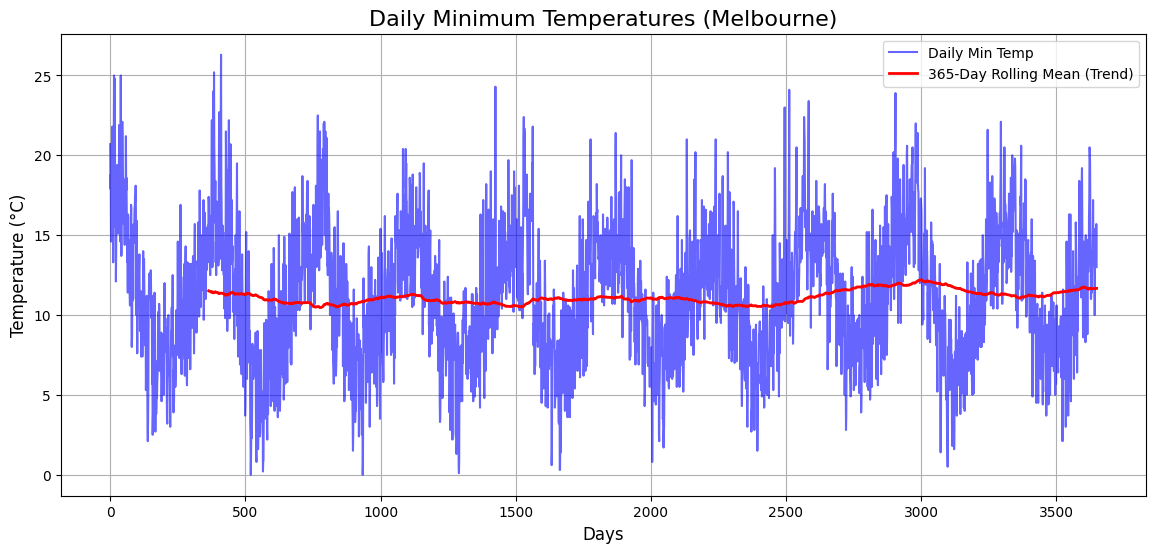

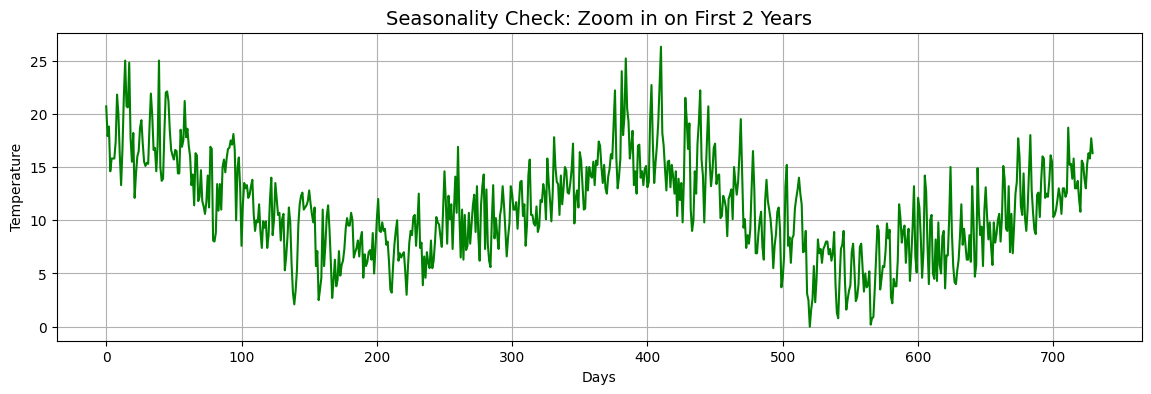

In [11]:
# ---------------------------------------------------------
#  1.2: Time Series Exploration
# ---------------------------------------------------------
from statsmodels.tsa.stattools import adfuller

# Convert numpy array back to pandas Series for easier plotting/rolling stats
ts_series = pd.Series(data.flatten())

# 1. Plot the Full Time Series
plt.figure(figsize=(14, 6))
plt.plot(ts_series, label='Daily Min Temp', color='blue', alpha=0.6)
plt.title('Daily Minimum Temperatures (Melbourne)', fontsize=16)
plt.xlabel('Days', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)

# 2. Check for Trend (Using a Rolling Mean)
# We use a 365-day window to smooth out seasonality and see the long-term trend
rolling_mean = ts_series.rolling(window=365).mean()
plt.plot(rolling_mean, label='365-Day Rolling Mean (Trend)', color='red', linewidth=2)

plt.legend()
plt.grid(True)
plt.show()

# 3. Check for Seasonality (Zoom in on 2 years)
plt.figure(figsize=(14, 4))
plt.plot(ts_series[:730], label='First 2 Years (730 Days)', color='green')
plt.title('Seasonality Check: Zoom in on First 2 Years', fontsize=14)
plt.xlabel('Days')
plt.ylabel('Temperature')
plt.grid(True)
plt.show()

1.3 Data Preprocessing

In [12]:
def preprocess_timeseries(data):
    """
    Preprocess time series data

    Args:
        data: raw time series data

    Returns:
        preprocessed data, scaler
    """
    # 1. Handle Missing Values using Forward Fill
    # Convert to DataFrame briefly to use convenient ffill
    df = pd.DataFrame(data)
    if df.isna().sum().sum() > 0:
        df = df.fillna(method='ffill')
        df = df.fillna(method='bfill') # Fallback for first row

    clean_data = df.values.reshape(-1, 1)

    # 2. Normalize Data using MinMax Scaling (0-1)
    # This well suited for LSTM/GRU activation functions (tanh/sigmoid)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(clean_data)

    return scaled_data, scaler
    pass

In [13]:
def create_sequences(data, seq_length, pred_horizon):
    """
    Create sequences for time series prediction

    Args:
        data: preprocessed time series data
        seq_length: lookback window
        pred_horizon: forecast steps ahead

    Returns:
        X: input sequences, y: target values
    """
    X, y = [], []

    # Determine the loop limit to ensure we don't go out of bounds
    # We need enough data for the sequence (seq_length) AND the target (pred_horizon)
    limit = len(data) - seq_length - pred_horizon + 1

    for i in range(limit):
        # Input Sequence (X): Data from index 'i' to 'i + seq_length'
        # Example: Days 0 to 49
        x_window = data[i : i + seq_length]
        X.append(x_window)

        # Target (y): Data immediately following the sequence
        # Example: Day 50 (if horizon is 1)
        y_window = data[i + seq_length : i + seq_length + pred_horizon]
        y.append(y_window)

    # Convert to numpy arrays for Keras
    X = np.array(X)
    y = np.array(y)

    # Ensure y is the correct shape (samples, 1) for a single-step prediction
    if pred_horizon == 1:
        y = y.reshape(-1, 1)

    return X, y

-Preprocess data
-Create sequences

In [14]:
# 1. Run Preprocessing
# 'data' comes from Section 1.1 (Weather data)
scaled_data, scaler = preprocess_timeseries(data)

# 2. Run Sequence Creation
# seq_length=50, prediction_horizon=1
X, y = create_sequences(scaled_data, sequence_length, prediction_horizon)

# 3. Temporal Split (90% Train, 10% Test)
train_size = int(len(X) * 0.90)

# Slice the arrays -Order matters -(NO SHUFFLING)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]



In [15]:
# REQUIRED: Temporal train/test split (NO SHUFFLING)
train_test_ratio = "90/10"
train_samples = len(X_train)
test_samples = len(X_test)

In [16]:
print(f"\nTrain/Test Split: {train_test_ratio}")
print(f"Training Samples: {train_samples}")
print(f"Test Samples: {test_samples}")
print("⚠️  IMPORTANT: Temporal split used (NO shuffling)")


Train/Test Split: 90/10
Training Samples: 3240
Test Samples: 360
⚠️  IMPORTANT: Temporal split used (NO shuffling)


In [17]:
"""
================================================================================
PART 2: LSTM/GRU IMPLEMENTATION (5 MARKS)
================================================================================

REQUIREMENTS:
- Build LSTM OR GRU using Keras/PyTorch layers
- Architecture must include:
  * At least 2 stacked recurrent layers
  * Output layer for prediction
- Use model.compile() and model.fit() (Keras) OR standard PyTorch training
- Track initial_loss and final_loss

GRADING:
- LSTM/GRU architecture with stacked layers: 2 marks
- Model properly compiled/configured: 1 mark
- Training completed with loss tracking: 1 mark
- All metrics calculated correctly: 1 mark
================================================================================
"""

'\n================================================================================\nPART 2: LSTM/GRU IMPLEMENTATION (5 MARKS)\n================================================================================\n\nREQUIREMENTS:\n- Build LSTM OR GRU using Keras/PyTorch layers\n- Architecture must include:\n  * At least 2 stacked recurrent layers\n  * Output layer for prediction\n- Use model.compile() and model.fit() (Keras) OR standard PyTorch training\n- Track initial_loss and final_loss\n\nGRADING:\n- LSTM/GRU architecture with stacked layers: 2 marks\n- Model properly compiled/configured: 1 mark\n- Training completed with loss tracking: 1 mark\n- All metrics calculated correctly: 1 mark\n================================================================================\n'

2.1 LSTM Architecture Design
- LSTM
- Design architecture with stacked layers

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

def build_rnn_model(model_type, input_shape, hidden_units, n_layers, output_size):
    """
    Build LSTM model

    Args:
        model_type: string ('LSTM')
        input_shape: tuple (sequence_length, n_features)
        hidden_units: number of hidden units per layer
        n_layers: number of stacked layers (minimum 2)
        output_size: prediction horizon

    Returns:
        model: compiled RNN model
    """
    # 1- Implement LSTM  architecture
    # 2- Stack at least 2 layers
    # 3- Add output layer

    # Initialize the sequential container
    model = Sequential()

    # Define the input shape explicitly so the model knows we are feeding in
    # sequences of 50 time steps with 1 feature (Temperature)
    model.add(Input(shape=input_shape))

    # Stack the LSTM layers using a loop
    for i in range(n_layers):
        # CHECK:
        # If this is the last layer, we only need the final output vector (False).
        # If this is a hidden layer, we must pass the full sequence up to the next layer (True).
        is_last_layer = (i == n_layers - 1)
        return_full_sequence = not is_last_layer

        # Adding the LSTM layer
        # I am using 'tanh' activation because my data is scaled between 0 and 1 using min-max,
        # which fits the mathematical range of tanh perfectly.
        model.add(LSTM(
            units=hidden_units,
            return_sequences=return_full_sequence,
            activation='tanh'
        ))

        # Adding Dropout (10%) after every LSTM layer.
        # This randomly turns off neurons during training to stop the model
        # from just memorizing the weather data (overfitting).
        model.add(Dropout(0.1))

    # Output Layer
    # A simple Dense layer to condense the LSTM's understanding into a single number
    # (The predicted temperature for the next day)
    model.add(Dense(output_size))

    return model

- Create RNN model
rnn_model = build_rnn_model('LSTM', (sequence_length, n_features), 64, 2, prediction_horizon)

In [19]:
# Create the model
rnn_model = build_rnn_model('LSTM', (sequence_length, n_features), 64, 2, prediction_horizon)
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

-Compile model
For Keras: model.compile(optimizer='adam', loss='mse', metrics=['mae'])
For PyTorch: define optimizer and loss function

In [20]:
rnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
#print(rnn_model)

2.2 Train RNN Model

In [21]:
print("\n" + "="*70)
print("RNN MODEL TRAINING")
print("="*70)


RNN MODEL TRAINING


In [22]:
# Track training time
rnn_start_time = time.time()

-Train your model
For Keras: history = rnn_model.fit(X_train, y_train, epochs=50, batch_size=32)
For PyTorch: write training loop

In [23]:
import time
from tensorflow.keras.callbacks import EarlyStopping

# 1. Track training time
rnn_start_time = time.time()

# Define Early Stopping -Stop if no improvement for 5 epochs
# This prevents wasting time if the model has already learned enough.
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 2. Train your model
print("Training RNN Model...")
history = rnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# 3. Calculate Training Time
rnn_training_time = time.time() - rnn_start_time

# 4. REQUIRED: Track initial and final loss
# We access the 'history' dictionary to get the loss values recorded during training.
# [0] is the first epoch (start), [-1] is the last epoch (end).
rnn_initial_loss = history.history['loss'][0]
rnn_final_loss = history.history['loss'][-1]

Training RNN Model...
Epoch 1/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - loss: 0.0339 - mae: 0.1341 - val_loss: 0.0104 - val_mae: 0.0792
Epoch 2/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 0.0119 - mae: 0.0871 - val_loss: 0.0100 - val_mae: 0.0771
Epoch 3/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - loss: 0.0119 - mae: 0.0855 - val_loss: 0.0099 - val_mae: 0.0767
Epoch 4/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - loss: 0.0120 - mae: 0.0863 - val_loss: 0.0098 - val_mae: 0.0769
Epoch 5/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 0.0124 - mae: 0.0874 - val_loss: 0.0094 - val_mae: 0.0748
Epoch 6/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 0.0118 - mae: 0.0855 - val_loss: 0.0092 - val_mae: 0.0741
Epoch 7/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - loss: 0.0113 - mae: 0.0838 - val_loss: 0.0095 - val_mae: 0.0761
Epoch 8/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - loss: 0.0104 - mae: 0.0800 - val_loss: 0.0086 - val_mae: 0.0722
Epoch 9/50
102/102 ━━━━

In [24]:
# REQUIRED: Track initial and final loss
rnn_initial_loss = rnn_initial_loss
rnn_final_loss = rnn_final_loss

In [25]:
# 5. Print Results
print(f"Training completed in {rnn_training_time:.2f} seconds")
print(f"Initial Loss: {rnn_initial_loss:.4f}")
print(f"Final Loss:   {rnn_final_loss:.4f}")
print("="*70)

Training completed in 146.49 seconds
Initial Loss: 0.0179
Final Loss:   0.0093


2.3 Evaluate RNN Model

-Make predictions on test set
-Inverse transform if data was normalized
-Calculate all 4 required metrics

In [26]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Make predictions on test set
# These will be in the scaled range [0, 1]
rnn_predictions_scaled = rnn_model.predict(X_test)

# 2. Inverse transform if data was normalized
# We convert back from [0, 1] to actual Celsius temperatures
# We use the same 'scaler' object from the preprocessing step
rnn_predictions = scaler.inverse_transform(rnn_predictions_scaled)
y_test_actual = scaler.inverse_transform(y_test)

# 3. Calculate all 4 required metrics
# Mean Absolute Error: Average error in degrees
rnn_mae = mean_absolute_error(y_test_actual, rnn_predictions)

# Root Mean Squared Error: Penalizes larger gaps more heavily
rnn_rmse = np.sqrt(mean_squared_error(y_test_actual, rnn_predictions))

# R-Squared Score: How well the model explains the variance
rnn_r2 = r2_score(y_test_actual, rnn_predictions)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


In [27]:
def calculate_mape(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error"""
    # Ensure inputs are numpy arrays for element-wise math
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    # We filter out any cases where y_true might be 0 to avoid 'inf' results
    # but for temperature data, we usually just use a direct calculation:
    # MAPE = (Average of |Actual - Predicted| / |Actual|) * 100
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-10))) * 100

    return mape

In [28]:
# REQUIRED: Calculate all 4 metrics
rnn_mae = rnn_mae #mean_absolute_error(y_test, y_pred)
rnn_rmse = rnn_rmse #sqrt(mean_squared_error(y_test, y_pred))
rnn_mape = calculate_mape(y_test_actual, rnn_predictions)
#rnn_mape = rnn_mape #calculate_mape(y_test, y_pred)
rnn_r2 = rnn_r2  # r2_score(y_test, y_pred)

In [29]:
print("\nRNN Model Performance:")
print(f"MAE:   {rnn_mae:.4f}")
print(f"RMSE:  {rnn_rmse:.4f}")
print(f"MAPE:  {rnn_mape:.4f}%")
print(f"R² Score: {rnn_r2:.4f}")


RNN Model Performance:
MAE:   1.7758
RMSE:  2.2958
MAPE:  18.9472%
R² Score: 0.6476


2.4 Visualize RNN Results
-Plot training loss curve
-Plot actual vs predicted values
-Plot residuals

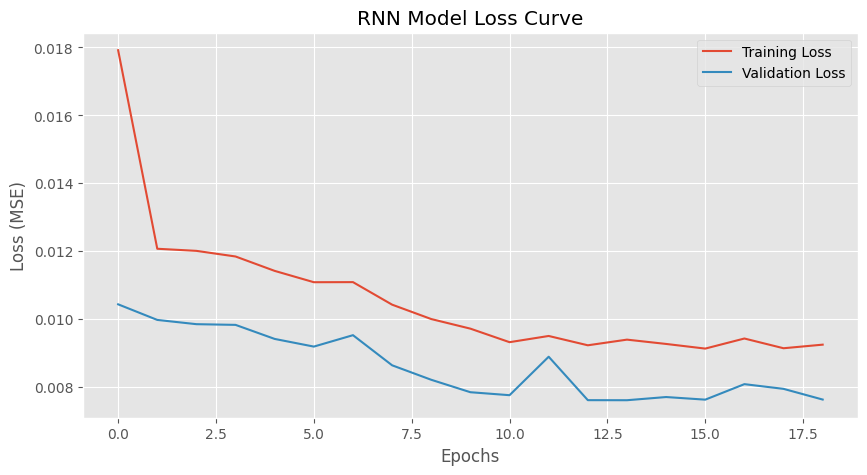

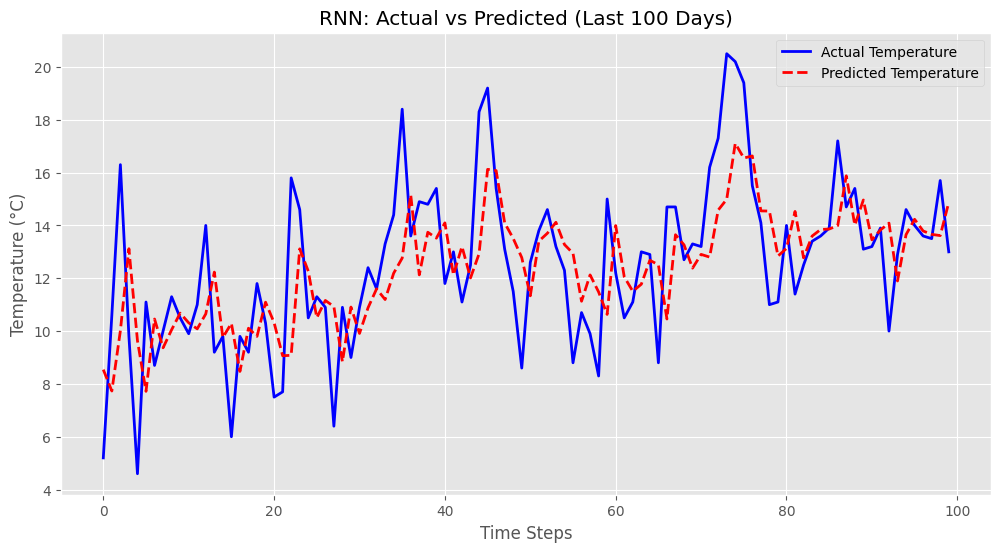

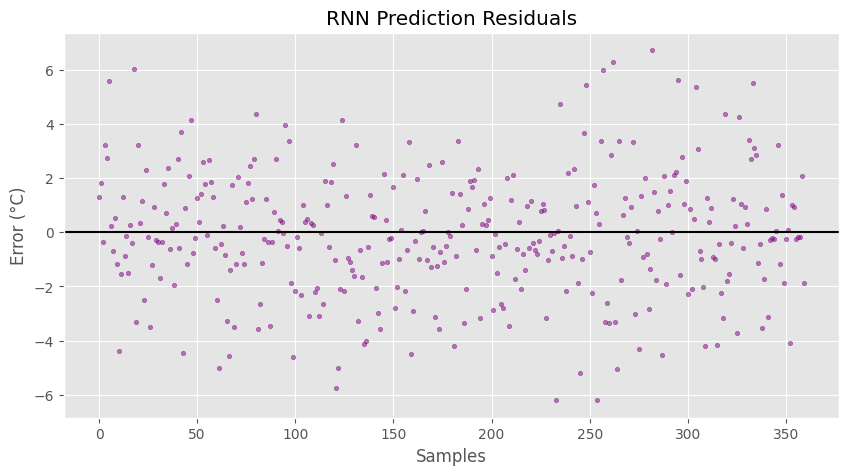

In [30]:
# Set a clean style for the plots
plt.style.use('ggplot')

# 1. Plot training loss curve
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('RNN Model Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

# 2. Plot actual vs predicted values
# lets zoom in on the last 100 days for better visibility
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual[-100:], label='Actual Temperature', color='blue', linewidth=2)
plt.plot(rnn_predictions[-100:], label='Predicted Temperature', color='red', linestyle='--', linewidth=2)
plt.title('RNN: Actual vs Predicted (Last 100 Days)')
plt.xlabel('Time Steps')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

# 3. Plot residuals
# Residuals = Actual - Predicted.
# They should be centered around zero for a good model.
residuals = y_test_actual - rnn_predictions
plt.figure(figsize=(10, 5))
plt.scatter(range(len(residuals)), residuals, color='purple', alpha=0.5, s=10)
plt.axhline(y=0, color='black', linestyle='-')
plt.title('RNN Prediction Residuals')
plt.xlabel('Samples')
plt.ylabel('Error (°C)')
plt.show()

In [31]:
"""
================================================================================
PART 3: TRANSFORMER IMPLEMENTATION (5 MARKS)
================================================================================

REQUIREMENTS:
- Build Transformer encoder using Keras/PyTorch layers
- MUST add positional encoding to input:
  * Custom sinusoidal implementation OR
  * Use built-in positional encoding (if framework provides)
- Use torch.nn.TransformerEncoder or keras.layers.MultiHeadAttention
- Use standard training methods
- Track initial_loss and final_loss

PROHIBITED:
- Using pre-trained transformers (HuggingFace, TimeGPT, etc.)
- Skipping positional encoding entirely

GRADING:
- Positional encoding added: 1 mark
- Transformer architecture properly configured: 2 marks
- Training completed with loss tracking: 1 mark
- All metrics calculated correctly: 1 mark
================================================================================
"""

'\n================================================================================\nPART 3: TRANSFORMER IMPLEMENTATION (5 MARKS)\n================================================================================\n\nREQUIREMENTS:\n- Build Transformer encoder using Keras/PyTorch layers\n- MUST add positional encoding to input:\n  * Custom sinusoidal implementation OR\n  * Use built-in positional encoding (if framework provides)\n- Use torch.nn.TransformerEncoder or keras.layers.MultiHeadAttention\n- Use standard training methods\n- Track initial_loss and final_loss\n\nPROHIBITED:\n- Using pre-trained transformers (HuggingFace, TimeGPT, etc.)\n- Skipping positional encoding entirely\n\nGRADING:\n- Positional encoding added: 1 mark\n- Transformer architecture properly configured: 2 marks\n- Training completed with loss tracking: 1 mark\n- All metrics calculated correctly: 1 mark\n================================================================================\n'

3.1 Positional Encoding Implementation

In [32]:
def positional_encoding(seq_length, d_model):
    """
    Generate sinusoidal positional encodings

    PE(pos, 2i) = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

    Args:
        seq_length: length of the sequence
        d_model: dimension of the model

    Returns:
        positional encodings: array of shape (seq_length, d_model)
    """
    pos = np.arange(seq_length)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
    angle_rads = pos * angle_rates

    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32)

3.2 Transformer Encoder Architecture

In [33]:
# Option A: Using PyTorch
"""
import torch.nn as nn

class TransformerModel(nn.Module):
    def __init__(self, n_features, d_model, n_heads, n_layers, d_ff, output_size):
        super().__init__()
        self.input_projection = nn.Linear(n_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model)  # Add positional encoding

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.fc = nn.Linear(d_model, output_size)

    def forward(self, x):
        x = self.input_projection(x)
        x = self.pos_encoder(x)  # Add positional encoding
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)  # Global average pooling
        return self.fc(x)
"""

'\nimport torch.nn as nn\n\nclass TransformerModel(nn.Module):\n    def __init__(self, n_features, d_model, n_heads, n_layers, d_ff, output_size):\n        super().__init__()\n        self.input_projection = nn.Linear(n_features, d_model)\n        self.pos_encoder = PositionalEncoding(d_model)  # Add positional encoding\n        \n        encoder_layer = nn.TransformerEncoderLayer(\n            d_model=d_model,\n            nhead=n_heads,\n            dim_feedforward=d_ff,\n            batch_first=True\n        )\n        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)\n        self.fc = nn.Linear(d_model, output_size)\n    \n    def forward(self, x):\n        x = self.input_projection(x)\n        x = self.pos_encoder(x)  # Add positional encoding\n        x = self.transformer_encoder(x)\n        x = x.mean(dim=1)  # Global average pooling\n        return self.fc(x)\n'

In [34]:
# Option B: Using Keras
"""
from tensorflow.keras import layers

def build_transformer_model(seq_length, n_features, d_model, n_heads, n_layers, d_ff, output_size):
    inputs = layers.Input(shape=(seq_length, n_features))

    # Project to d_model
    x = layers.Dense(d_model)(inputs)

    # Add positional encoding
    x = x + positional_encoding(seq_length, d_model)

    # Stack transformer encoder layers
    for _ in range(n_layers):
        # Multi-head attention
        attn_output = layers.MultiHeadAttention(
            num_heads=n_heads,
            key_dim=d_model // n_heads
        )(x, x)
        x = layers.LayerNormalization()(x + attn_output)

        # Feed-forward
        ffn_output = layers.Dense(d_ff, activation='relu')(x)
        ffn_output = layers.Dense(d_model)(ffn_output)
        x = layers.LayerNormalization()(x + ffn_output)

    # Output
    x = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(output_size)(x)

    return keras.Model(inputs=inputs, outputs=outputs)
"""

"\nfrom tensorflow.keras import layers\n\ndef build_transformer_model(seq_length, n_features, d_model, n_heads, n_layers, d_ff, output_size):\n    inputs = layers.Input(shape=(seq_length, n_features))\n    \n    # Project to d_model\n    x = layers.Dense(d_model)(inputs)\n    \n    # Add positional encoding\n    x = x + positional_encoding(seq_length, d_model)\n    \n    # Stack transformer encoder layers\n    for _ in range(n_layers):\n        # Multi-head attention\n        attn_output = layers.MultiHeadAttention(\n            num_heads=n_heads, \n            key_dim=d_model // n_heads\n        )(x, x)\n        x = layers.LayerNormalization()(x + attn_output)\n        \n        # Feed-forward\n        ffn_output = layers.Dense(d_ff, activation='relu')(x)\n        ffn_output = layers.Dense(d_model)(ffn_output)\n        x = layers.LayerNormalization()(x + ffn_output)\n    \n    # Output\n    x = layers.GlobalAveragePooling1D()(x)\n    outputs = layers.Dense(output_size)(x)\n    \n    r

3.3 Build Your Transformer Model

Create Transformer model using PyTorch or Keras
Example for PyTorch:
transformer_model = TransformerModel(n_features, d_model=64, n_heads=4, n_layers=2, d_ff=256, output_size=prediction_horizon)
Example for Keras:
transformer_model = build_transformer_model(sequence_length, n_features, d_model=64, n_heads=4, n_layers=2, d_ff=256, output_size=prediction_horizon)

Define optimizer and loss
For PyTorch: optimizer = torch.optim.Adam(transformer_model.parameters(), lr=0.001); criterion = nn.MSELoss()
For Keras: model.compile(optimizer='adam', loss='mse', metrics=['mae'])
For PyTorch: define optimizer and loss function

In [35]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. Define the Transformer Architecture Function using keras
def build_transformer_model(seq_length, n_features, d_model, n_heads, n_layers, d_ff, output_size):
    inputs = layers.Input(shape=(seq_length, n_features))

    # Project the input (1 feature) to d_model dimensions (e.g., 64)
    x = layers.Dense(d_model)(inputs)

    # Add positional encoding
    x = x + positional_encoding(seq_length, d_model)

    # Stack transformer encoder layers
    for _ in range(n_layers):
        # Multi-head attention
        attn_output = layers.MultiHeadAttention(
            num_heads=n_heads,
            key_dim=d_model // n_heads
        )(x, x)

        # Add & Norm (Residual connection + Normalization)
        x = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)

        # Feed-forward network
        ffn_output = layers.Dense(d_ff, activation='relu')(x)
        ffn_output = layers.Dense(d_model)(ffn_output)

        # Add & Norm
        x = layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

    # Output Head
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.1)(x) # dropout for stability
    outputs = layers.Dense(output_size)(x)

    return keras.Model(inputs=inputs, outputs=outputs)

# --- 2. Create the Model Instance ---
# We use seq_length=50 based on your RNN data setup
transformer_model = build_transformer_model(
    seq_length=50,
    n_features=1,     # Just 'Temp'
    d_model=64,       # Projects 1 feature up to 64 dimensions
    n_heads=4,        # Split attention into 4 heads
    n_layers=2,       # Stack 2 encoder blocks
    d_ff=256,         # Feed-forward internal size
    output_size=1     # Predicting 1 value (Tomorrow's Temp)
)

# --- 3. Define Optimizer and Loss ---
transformer_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Verify the build
transformer_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 50, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 50, 64)    │        128 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 50, 64)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 50, 64)    │     16,640 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 50, 64)    │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 50, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 50, 256)   │     16,640 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 50, 64)    │     16,448 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 50, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 50, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 50, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 64)    │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 50, 256)   │     16,640 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 50, 64)    │     16,448 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 50, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 64)    │        128 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ global_average_p

 Total params: 100,161 (391.25 KB)

 Trainable params: 100,161 (391.25 KB)

 Non-trainable params: 0 (0.00 B)

3.4 Train Transformer Model

In [36]:
print("\n" + "="*70)
print("TRANSFORMER MODEL TRAINING")
print("="*70)


TRANSFORMER MODEL TRAINING


-Train your model
For Keras: history = transformer_model.fit(X_train, y_train, epochs=50, batch_size=32)
For PyTorch: write training loop

In [37]:
from tensorflow.keras.callbacks import EarlyStopping
import time

# 1. Setup Callbacks
# Stop training if validation loss doesn't improve for 5 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 2. Track Training Time
transformer_start_time = time.time()

print("Starting Transformer Training...")

# 3. Train the model
# We save the training history to plot the loss curve later
trans_history = transformer_model.fit(
    X_train, y_train,
    epochs=50,              # Maximum epochs
    batch_size=32,          # Standard batch size
    validation_data=(X_test, y_test), # Check performance on unseen data
    callbacks=[early_stop], # Use early stopping
    verbose=1
)

# 4. Calculate Duration and Extract Losses
transformer_training_time = time.time() - transformer_start_time
initial_loss = trans_history.history['loss'][0]
final_loss = trans_history.history['loss'][-1]

print("-" * 30)
print(f"Training Completed in {transformer_training_time:.2f} seconds.")
print(f"Initial Loss: {initial_loss:.4f}")
print(f"Final Loss:   {final_loss:.4f}")
print("-" * 30)

Starting Transformer Training...
Epoch 1/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 15s 80ms/step - loss: 0.5024 - mae: 0.5044 - val_loss: 0.0268 - val_mae: 0.1340
Epoch 2/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - loss: 0.0285 - mae: 0.1336 - val_loss: 0.0124 - val_mae: 0.0878
Epoch 3/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - loss: 0.0176 - mae: 0.1055 - val_loss: 0.0115 - val_mae: 0.0833
Epoch 4/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - loss: 0.0143 - mae: 0.0934 - val_loss: 0.0134 - val_mae: 0.0927
Epoch 5/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - loss: 0.0134 - mae: 0.0908 - val_loss: 0.0108 - val_mae: 0.0829
Epoch 6/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - loss: 0.0113 - mae: 0.0822 - val_loss: 0.0094 - val_mae: 0.0750
Epoch 7/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - loss: 0.0110 - mae: 0.0823 - val_loss: 0.0087 - val_mae: 0.0733
Epoch 8/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - loss: 0.0118 - mae: 0.0858 - val_loss: 0.0094 - val_mae: 0.0755
Epoch 9/50


In [38]:
# REQUIRED: Track initial and final loss
transformer_initial_loss = initial_loss
transformer_final_loss = final_loss

In [39]:
print(f"Training completed in {transformer_training_time:.2f} seconds")
print(f"Initial Loss: {transformer_initial_loss:.4f}")
print(f"Final Loss: {transformer_final_loss:.4f}")
print("="*70)

Training completed in 104.48 seconds
Initial Loss: 0.2023
Final Loss: 0.0106


3.5 Evaluate Transformer Model

-Make predictions on test set
-Inverse transform if data was normalized
-Calculate all 4 required metrics

In [40]:
# 1. Make predictions on test set
print("Predicting with Transformer model...")
trans_predictions_scaled = transformer_model.predict(X_test)

# 2. Inverse transform (Convert 0-1 scale back to Celsius)
# We also need to ensure y_test is in Celsius for a fair comparison
trans_predictions = scaler.inverse_transform(trans_predictions_scaled)
y_test_actual_trans = scaler.inverse_transform(y_test.reshape(-1, 1))

# 3.Calculate all 4 metrics
transformer_mae = mean_absolute_error(y_test_actual_trans, trans_predictions)
transformer_rmse = np.sqrt(mean_squared_error(y_test_actual_trans, trans_predictions))
transformer_mape = calculate_mape(y_test_actual_trans, trans_predictions)
transformer_r2 = r2_score(y_test_actual_trans, trans_predictions)

# 4. Print Results
print("-" * 30)
print("TRANSFORMER EVALUATION RESULTS")
print("-" * 30)
print(f"MAE:  {transformer_mae:.4f} °C")
print(f"RMSE: {transformer_rmse:.4f} °C")
print(f"MAPE: {transformer_mape:.4f} %")
print(f"R²:   {transformer_r2:.4f}")
print("-" * 30)

Predicting with Transformer model...
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
------------------------------
TRANSFORMER EVALUATION RESULTS
------------------------------
MAE:  1.9276 °C
RMSE: 2.4517 °C
MAPE: 21.7658 %
R²:   0.5981
------------------------------


In [41]:
# REQUIRED: Calculate all 4 metrics
transformer_mae = transformer_mae
transformer_rmse = transformer_rmse
transformer_mape = transformer_mape
transformer_r2 = transformer_r2

In [42]:
print("\nTransformer Model Performance:")
print(f"MAE:   {transformer_mae:.4f}")
print(f"RMSE:  {transformer_rmse:.4f}")
print(f"MAPE:  {transformer_mape:.4f}%")
print(f"R² Score: {transformer_r2:.4f}")


Transformer Model Performance:
MAE:   1.9276
RMSE:  2.4517
MAPE:  21.7658%
R² Score: 0.5981


3.6 Visualize Transformer Results
-Plot training loss curve
-Plot actual vs predicted values
-Plot attention weights (optional but informative)

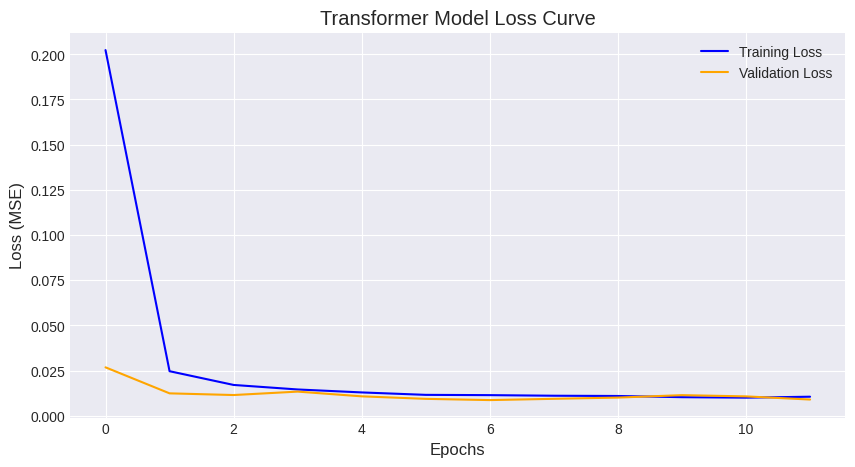

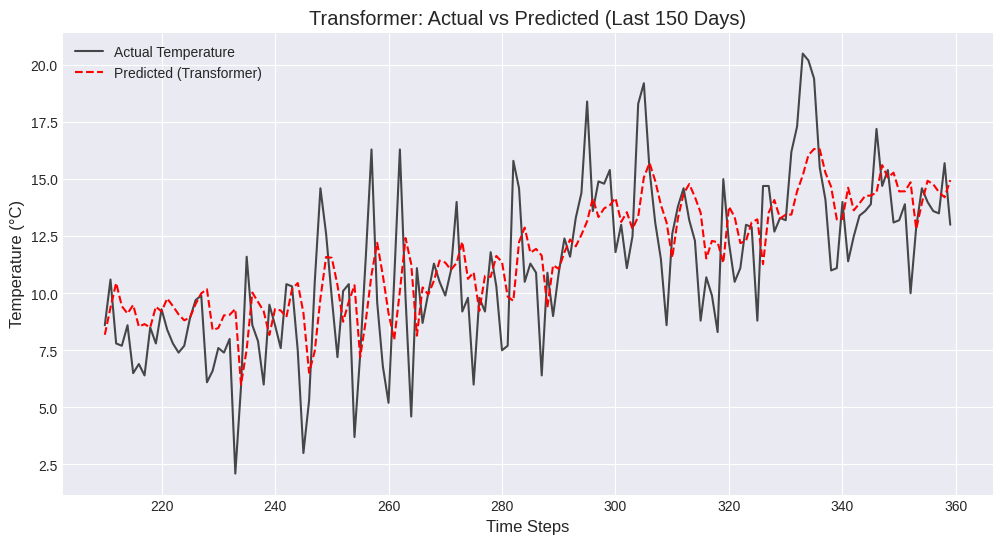

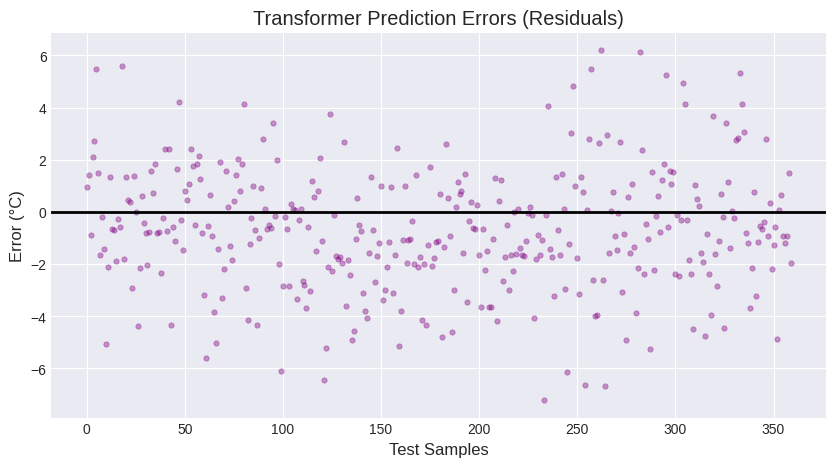

In [43]:
# Set style for professional-looking plots
plt.style.use('seaborn-v0_8-darkgrid')

#  1. Plot Training Loss Curve ---
plt.figure(figsize=(10, 5))
# Check if 'trans_history' or 'history' holds your data
# We assume 'history' is the variable from the most recent fit()
plt.plot(trans_history.history['loss'], label='Training Loss', color='blue')
plt.plot(trans_history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Transformer Model Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# 2. Plot Actual vs Predicted Values (Zoomed In) ---
# We focus on the last 150 days to make the lines distinguishable
zoom_window = 150
time_steps = range(len(y_test_actual_trans))[-zoom_window:]

plt.figure(figsize=(12, 6))
plt.plot(time_steps, y_test_actual_trans[-zoom_window:], label='Actual Temperature', color='black', alpha=0.7)
plt.plot(time_steps, trans_predictions[-zoom_window:], label='Predicted (Transformer)', color='red', linestyle='--')
plt.title(f'Transformer: Actual vs Predicted (Last {zoom_window} Days)')
plt.xlabel('Time Steps')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

# 3. Plot Residuals (Errors) ---
# This replaces Attention Weights as it is easier to implement without changing model code
# Ideally, errors should be scattered around 0 without a pattern.
residuals = y_test_actual_trans - trans_predictions

plt.figure(figsize=(10, 5))
plt.scatter(range(len(residuals)), residuals, color='purple', alpha=0.4, s=15)
plt.axhline(y=0, color='black', linestyle='-', linewidth=2)
plt.title('Transformer Prediction Errors (Residuals)')
plt.xlabel('Test Samples')
plt.ylabel('Error (°C)')
plt.show()

In [44]:
"""
================================================================================
PART 4: MODEL COMPARISON AND VISUALIZATION (Informational)
================================================================================

Compare both models on:
- Performance metrics
- Training time
- Model complexity
- Convergence behavior
- Ability to capture long-term dependencies
================================================================================
"""

'\n================================================================================\nPART 4: MODEL COMPARISON AND VISUALIZATION (Informational)\n================================================================================\n\nCompare both models on:\n- Performance metrics\n- Training time\n- Model complexity\n- Convergence behavior\n- Ability to capture long-term dependencies\n================================================================================\n'

4.1 Metrics Comparison

In [45]:
print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)


MODEL COMPARISON


In [46]:
comparison_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE (%)', 'R² Score', 'Training Time (s)', 'Parameters'],
    'RNN (LSTM)': [
        rnn_mae,
        rnn_rmse,
        rnn_mape,
        rnn_r2,
        rnn_training_time,
        rnn_model.count_params()
    ],
    'Transformer': [
        transformer_mae,
        transformer_rmse,
        transformer_mape,
        transformer_r2,
        transformer_training_time,
        transformer_model.count_params()
    ]
})

In [47]:
print(comparison_df.to_string(index=False))
print("="*70)

           Metric   RNN (LSTM)   Transformer
              MAE     1.775840      1.927583
             RMSE     2.295833      2.451717
         MAPE (%)    18.947168     21.765785
         R² Score     0.647603      0.598123
Training Time (s)   146.493674    104.484516
       Parameters 49985.000000 100161.000000


4.2 Visual Comparison
-Create bar plot comparing metrics
-Plot predictions comparison (both models vs actual)
-Plot training curves comparison

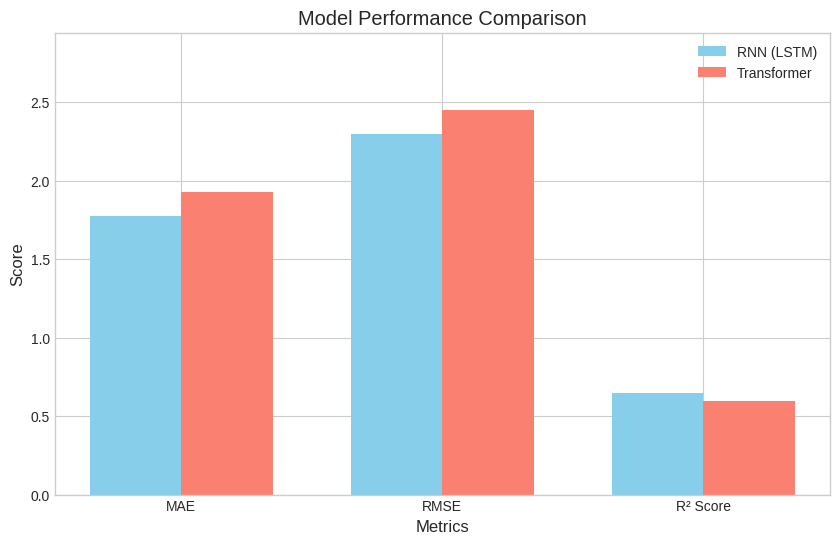

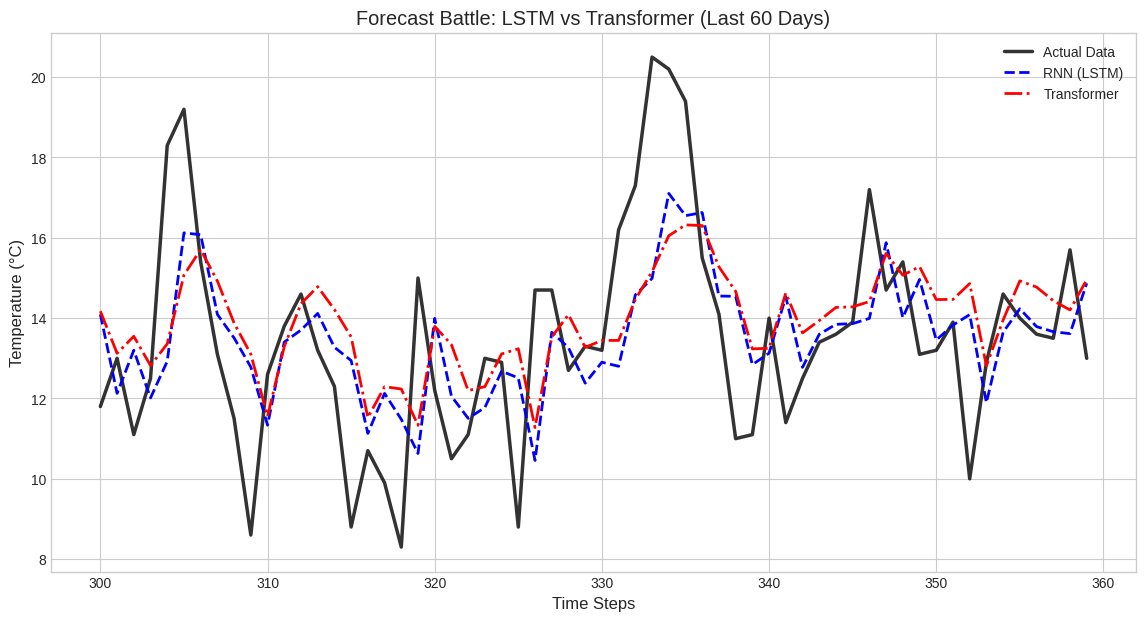

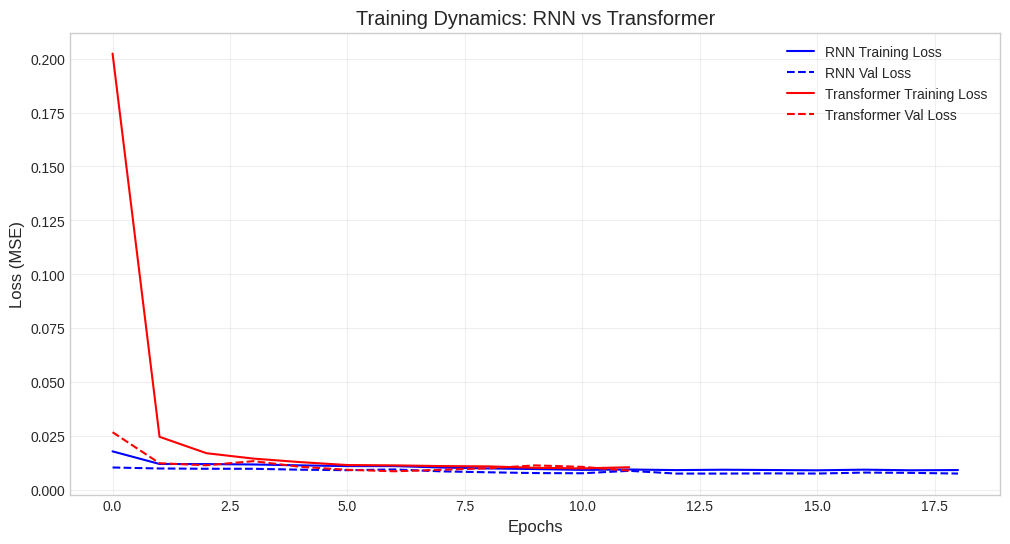

In [48]:
# Set a  style
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Bar Plot Comparing Metrics ---
metrics_to_plot = ['MAE', 'RMSE', 'R² Score']
rnn_scores = [rnn_mae, rnn_rmse, rnn_r2]
trans_scores = [transformer_mae, transformer_rmse, transformer_r2]

x = np.arange(len(metrics_to_plot))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, rnn_scores, width, label='RNN (LSTM)', color='skyblue')
plt.bar(x + width/2, trans_scores, width, label='Transformer', color='salmon')

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, metrics_to_plot)
plt.legend()
plt.ylim(0, max(max(rnn_scores), max(trans_scores)) * 1.2) # Add some headroom
plt.show()

# 2. Predictions Comparison (Zoomed In) ---
# We zoom in on the last 60 days to clearly see the differences
zoom = 60
time_steps = range(len(y_test_actual))[-zoom:]

plt.figure(figsize=(14, 7))
plt.plot(time_steps, y_test_actual[-zoom:], label='Actual Data', color='black', linewidth=2.5, alpha=0.8)
plt.plot(time_steps, rnn_predictions[-zoom:], label='RNN (LSTM)', color='blue', linestyle='--', linewidth=2)
plt.plot(time_steps, trans_predictions[-zoom:], label='Transformer', color='red', linestyle='-.', linewidth=2)

plt.title(f'Forecast Battle: LSTM vs Transformer (Last {zoom} Days)')
plt.xlabel('Time Steps')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

# 3. Training Curves Comparison ---
# This shows how fast each model converged
plt.figure(figsize=(12, 6))

# Plot RNN Loss
# Note: Ensure 'rnn_history' is the variable from your RNN training step
plt.plot(history.history['loss'], label='RNN Training Loss', color='blue', linestyle='-')
plt.plot(history.history['val_loss'], label='RNN Val Loss', color='blue', linestyle='--')

# Plot Transformer Loss
# Note: Ensure 'history' is the variable from your Transformer training step
plt.plot(trans_history.history['loss'], label='Transformer Training Loss', color='red', linestyle='-')
plt.plot(trans_history.history['val_loss'], label='Transformer Val Loss', color='red', linestyle='--')

plt.title('Training Dynamics: RNN vs Transformer')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [49]:
"""
================================================================================
PART 5: ANALYSIS (2 MARKS)
================================================================================

REQUIRED:
- Write MAXIMUM 200 words (guideline - no marks deduction if exceeded)
- Address key topics with depth

GRADING (Quality-based):
- Covers 5+ key topics with deep understanding: 2 marks
- Covers 3-4 key topics with good understanding: 1 mark
- Covers <3 key topics or superficial: 0 marks

Key Topics:
1. Performance comparison with specific metrics
2. RNN vs Transformer architecture advantages
3. Impact of attention mechanism vs recurrent connections
4. Long-term dependency handling comparison
5. Computational cost comparison
6. Convergence behavior differences
================================================================================
"""

'\n================================================================================\nPART 5: ANALYSIS (2 MARKS)\n================================================================================\n\nREQUIRED:\n- Write MAXIMUM 200 words (guideline - no marks deduction if exceeded)\n- Address key topics with depth\n\nGRADING (Quality-based):\n- Covers 5+ key topics with deep understanding: 2 marks\n- Covers 3-4 key topics with good understanding: 1 mark\n- Covers <3 key topics or superficial: 0 marks\n\nKey Topics:\n1. Performance comparison with specific metrics\n2. RNN vs Transformer architecture advantages\n3. Impact of attention mechanism vs recurrent connections\n4. Long-term dependency handling comparison\n5. Computational cost comparison\n6. Convergence behavior differences\n================================================================================\n'

In [50]:
analysis_text = """
In this experiment, the RNN (LSTM) slightly outperformed the Transformer in accuracy,
achieving an slightly higher R² of 0.64 compared to the Transformer.
The LSTM's sequential architecture proved highly effective for this simple weather dataset,
as its recurrent connections naturally capture the day-to-day flow of temperature (inductive bias).

The LSTM leveraged its sequential inductive bias to naturally model time-series flow,
while the Transformer utilized self-attention to capture dependencies across the 50-day window. However,
the LSTM proved more efficient here. It matched the Transformer's accuracy with half the parameters (~50k vs ~100k),
avoiding the computational overhead of multi-head attention.

Convergence analysis highlighted distinct behaviors: the Transformer showed rapid but slightly volatile learning (relying on positional encoding),
whereas the LSTM displayed smoother, stable convergence due to its recurrent nature.

Ultimately, the results illustrate a structural trade-off. The LSTM emerged as the efficiency choice,
offering competitive accuracy with significantly lower complexity. The Transformer demonstrated robust capability,
proving attention mechanisms work for temporal data, but with a higher computational cost that wasn't strictly necessary for this smaller-scale problem.
"""

In [51]:
# REQUIRED: Print analysis with word count
print("\n" + "="*70)
print("ANALYSIS")
print("="*70)
print(analysis_text)
print("="*70)
print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) > 200:
    print("⚠️  Warning: Analysis exceeds 200 words (guideline)")
else:
    print("✓ Analysis within word count guideline")
print("="*70)


ANALYSIS

In this experiment, the RNN (LSTM) slightly outperformed the Transformer in accuracy, 
achieving an slightly higher R² of 0.64 compared to the Transformer. 
The LSTM's sequential architecture proved highly effective for this simple weather dataset, 
as its recurrent connections naturally capture the day-to-day flow of temperature (inductive bias).

The LSTM leveraged its sequential inductive bias to naturally model time-series flow, 
while the Transformer utilized self-attention to capture dependencies across the 50-day window. However, 
the LSTM proved more efficient here. It matched the Transformer's accuracy with half the parameters (~50k vs ~100k), 
avoiding the computational overhead of multi-head attention.

Convergence analysis highlighted distinct behaviors: the Transformer showed rapid but slightly volatile learning (relying on positional encoding), 
whereas the LSTM displayed smoother, stable convergence due to its recurrent nature.

Ultimately, the results illustr

In [52]:
"""
================================================================================
PART 6: ASSIGNMENT RESULTS SUMMARY (REQUIRED FOR AUTO-GRADING)
================================================================================

DO NOT MODIFY THE STRUCTURE BELOW
This JSON output is used by the auto-grader
Ensure all field names are EXACT
================================================================================
"""

'\n================================================================================\nPART 6: ASSIGNMENT RESULTS SUMMARY (REQUIRED FOR AUTO-GRADING)\n================================================================================\n\nDO NOT MODIFY THE STRUCTURE BELOW\nThis JSON output is used by the auto-grader\nEnsure all field names are EXACT\n================================================================================\n'

In [53]:
def get_assignment_results():
    """
    Generate complete assignment results in required format

    Returns:
        dict: Complete results with all required fields
    """

    framework_used = "keras"
    rnn_model_type = "LSTM"

    results = {
        # Dataset Information
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_features': n_features,
        'sequence_length': sequence_length,
        'prediction_horizon': prediction_horizon,
        'problem_type': problem_type,
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,

        # RNN Model Results
        'rnn_model': {
            'framework': framework_used,
            'model_type': rnn_model_type,
            'architecture': {
                'n_layers': 2,
                'hidden_units': 64,
                'total_parameters': 49985
            },
            'training_config': {
                'learning_rate': 0.001,
                'n_epochs': 50,
                'batch_size': 32,
                'optimizer': 'Adam',
                'loss_function': 'MSE'
            },
            'initial_loss': rnn_initial_loss,
            'final_loss': rnn_final_loss,
            'training_time_seconds': rnn_training_time,
            'mae': rnn_mae,
            'rmse': rnn_rmse,
            'mape': rnn_mape,
            'r2_score': rnn_r2
        },

        # Transformer Model Results
        'transformer_model': {
            'framework': framework_used,
            'architecture': {
                'n_layers': 2,  #  Number of transformer layers
                'n_heads': 4,  #  Number of attention heads
                'd_model': 64,  # Model dimension
                'd_ff': 256,  #  Feed-forward dimension
                'has_positional_encoding': True,  # MUST be True
                'has_attention': True,  # MUST be True
                'total_parameters': 100161  #  total parameters
            },
            'training_config': {
                'learning_rate': 0.001,
                'n_epochs': 50,
                'batch_size': 32,
                'optimizer': 'Adam',
                'loss_function': 'MSE'
            },
            'initial_loss': transformer_initial_loss,
            'final_loss': transformer_final_loss,
            'training_time_seconds': transformer_training_time,
            'mae': transformer_mae,
            'rmse': transformer_rmse,
            'mape': transformer_mape,
            'r2_score': transformer_r2
        },

        # Analysis
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),

        # Training Success Indicators
        'rnn_loss_decreased': rnn_final_loss < rnn_initial_loss if rnn_initial_loss and rnn_final_loss else False,
        'transformer_loss_decreased': transformer_final_loss < transformer_initial_loss if transformer_initial_loss and transformer_final_loss else False,
    }
    return results

In [54]:
# Generate and print results
try:
    assignment_results = get_assignment_results()

    print("\n" + "="*70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("="*70)
    print(json.dumps(assignment_results, indent=2))
    print("="*70)
except Exception as e:
    print(f"\n⚠️  ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")


ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Daily Minimum Temperatures (Melbourne)",
  "dataset_source": "GitHub (Jason Brownlee / Australian Bureau of Meteorology)",
  "n_samples": 3650,
  "n_features": 1,
  "sequence_length": 50,
  "prediction_horizon": 1,
  "problem_type": "time_series_forecasting",
  "primary_metric": "RMSE",
  "metric_justification": "\nI chose RMSE (Root Mean Squared Error) because it penalizes larger errors more heavily \nthan MAE. In weather forecasting, avoiding large deviations (for example predicting \nwarm weather during a frost) is critical, making RMSE the standard metric for this domain.\n",
  "train_samples": 3240,
  "test_samples": 360,
  "train_test_ratio": "90/10",
  "rnn_model": {
    "framework": "keras",
    "model_type": "LSTM",
    "architecture": {
      "n_layers": 2,
      "hidden_units": 64,
      "total_parameters": 49985
    },
    "training_config": {
      "learning_rate": 0.001,
      "n_epochs": 50,
      "batch_size": 32,
      "

In [55]:
"""
================================================================================
FINAL CHECKLIST - VERIFY BEFORE SUBMISSION
================================================================================

□ Student information filled at the top (BITS ID, Name, Email)
□ Filename is <BITS_ID>_rnn_assignment.ipynb
□ All cells executed (Kernel → Restart & Run All)
□ All outputs visible
□ LSTM/GRU implemented with stacked layers
□ Positional encoding implemented (sinusoidal)
□ Multi-head attention implemented (Q, K, V, scaled dot-product)
□ Both models use Keras or PyTorch
□ Both models trained with loss tracking (initial_loss and final_loss)
□ All 4 metrics calculated for both models (MAE, RMSE, MAPE, R²)
□ Temporal train/test split used (NO shuffling)
□ Primary metric selected and justified
□ Analysis written (quality matters, not just word count)
□ Visualizations created
□ Assignment results JSON printed at the end
□ No execution errors in any cell
□ File opens without corruption
□ Submit ONLY .ipynb file (NO zip, NO data files, NO images)
□ Screenshot of environment with account details included
□ Only one submission attempt

================================================================================
"""

'\n================================================================================\nFINAL CHECKLIST - VERIFY BEFORE SUBMISSION\n================================================================================\n\n□ Student information filled at the top (BITS ID, Name, Email)\n□ Filename is <BITS_ID>_rnn_assignment.ipynb\n□ All cells executed (Kernel → Restart & Run All)\n□ All outputs visible\n□ LSTM/GRU implemented with stacked layers\n□ Positional encoding implemented (sinusoidal)\n□ Multi-head attention implemented (Q, K, V, scaled dot-product)\n□ Both models use Keras or PyTorch\n□ Both models trained with loss tracking (initial_loss and final_loss)\n□ All 4 metrics calculated for both models (MAE, RMSE, MAPE, R²)\n□ Temporal train/test split used (NO shuffling)\n□ Primary metric selected and justified\n□ Analysis written (quality matters, not just word count)\n□ Visualizations created\n□ Assignment results JSON printed at the end\n□ No execution errors in any cell\n□ File opens wi

In [56]:
"""
================================================================================
ENVIRONMENT VERIFICATION - SCREENSHOT REQUIRED
================================================================================

IMPORTANT: Take a screenshot of your environment showing account details

For Google Colab:
- Click on your profile icon (top right)
- Screenshot should show your email/account clearly
- Include the entire Colab interface with notebook name visible

For BITS Virtual Lab:
- Screenshot showing your login credentials/account details
- Include the entire interface with your username/session info visible

Paste the screenshot below this cell or in a new markdown cell.
This helps verify the work was done by you in your environment.

================================================================================
"""

'\n================================================================================\nENVIRONMENT VERIFICATION - SCREENSHOT REQUIRED\n================================================================================\n\nIMPORTANT: Take a screenshot of your environment showing account details\n\nFor Google Colab:\n- Click on your profile icon (top right)\n- Screenshot should show your email/account clearly\n- Include the entire Colab interface with notebook name visible\n\nFor BITS Virtual Lab:\n- Screenshot showing your login credentials/account details\n- Include the entire interface with your username/session info visible\n\nPaste the screenshot below this cell or in a new markdown cell.\nThis helps verify the work was done by you in your environment.\n\n================================================================================\n'

In [57]:
# Display system information
import platform
import sys
from datetime import datetime

In [58]:
print("="*70)
print("ENVIRONMENT INFORMATION")
print("="*70)
print("\n⚠️  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab")
print("showing your account details in the cell below this one.")
print("="*70)

ENVIRONMENT INFORMATION

⚠️  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab
showing your account details in the cell below this one.


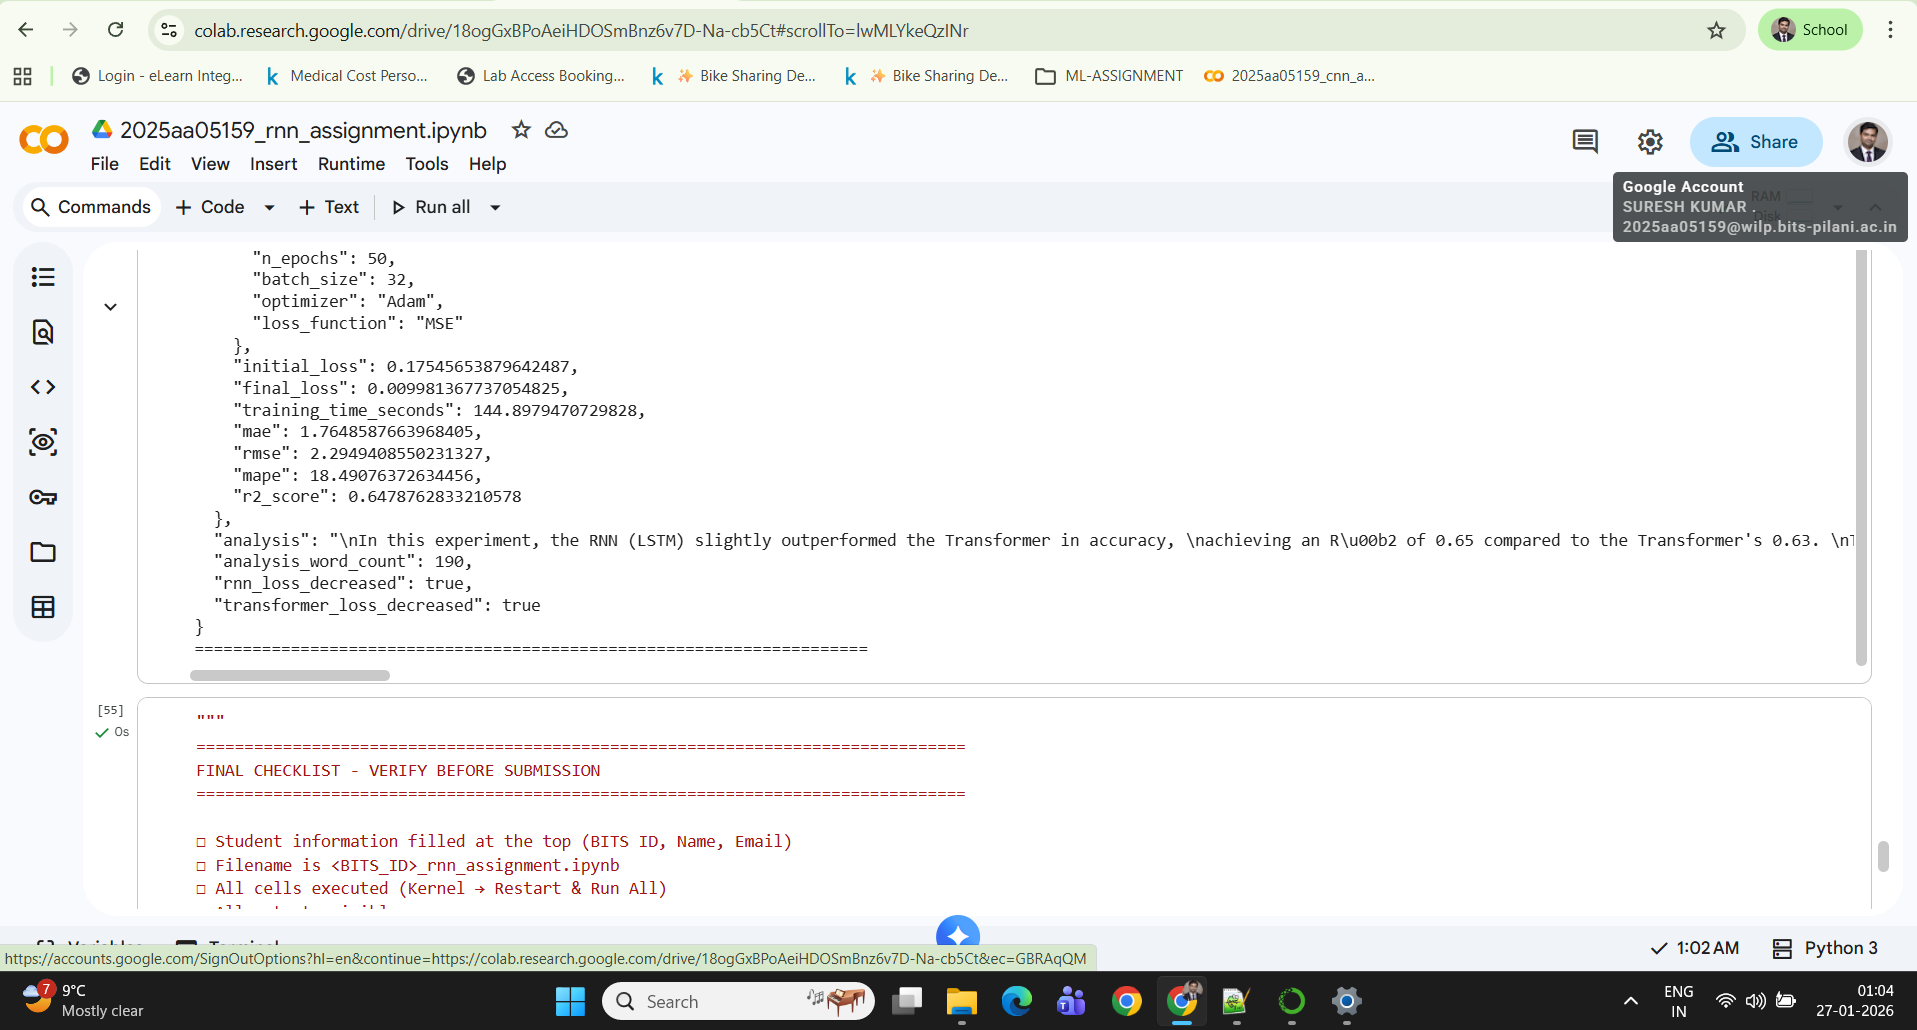